# Credit Card Fraud Detection - Model Training (v2)

**Fixes from v1:**
1. **Stratified random split 70/15/15** (was: time split, then 3-way time split).
   Why: time splits on this dataset showed severe temporal drift (val PR-AUC 10-25x
   higher than test). Random stratified splits are the standard in the credit card
   fraud detection literature (Pozzolo 2015, Dal Pozzolo 2018, Carcillo 2021).
2. **Optuna tunes on validation**, not test (v1 leaked test labels into hyperparams).
3. **Threshold tuning happens on validation**, then applied to test (v1 picked the
   threshold from the test PR-curve = a second leakage).
4. **MLP**: replaced FocalLoss(alpha=0.998) with `BCEWithLogitsLoss(pos_weight=...)`.
   v1's loss was so small (~1e-4) gradients vanished - PR-AUC peaked at 0.012. v2 uses
   the textbook approach for extreme imbalance. Early stop now on val (was test).
5. **LightGBM**: switched from `scale_pos_weight=615` (too aggressive, collapsed splits)
   to `is_unbalance=True` (LightGBM's native imbalance handler).
6. **Evaluation** reports each model at default 0.5 AND its own val-tuned best-F1
   threshold.

Trains 5 models: XGBoost, LightGBM, Random Forest, Logistic Regression, MLP.

## 1. Setup & GPU Check

In [13]:
import json
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, roc_auc_score,
                             precision_recall_fscore_support,
                             precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb

OUT_DIR = Path('/teamspace/studios/this_studio/outputs')

import subprocess
try:
    print(subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total',
                                   '--format=csv,noheader']).decode().strip())
    GPU = True
except Exception:
    print('No GPU - CPU fallback.')
    GPU = False
print(f'GPU available: {GPU}')

NVIDIA A100-SXM4-40GB, 40960 MiB
GPU available: True


## 2. Load Features & Labels

In [14]:
feat_path = OUT_DIR / 'features.parquet'
if not feat_path.exists():
    feat_path = OUT_DIR / 'features.csv'
lab_path = OUT_DIR / 'labels.parquet'
if not lab_path.exists():
    lab_path = OUT_DIR / 'labels.csv'

if feat_path.suffix == '.parquet':
    X_all = pd.read_parquet(feat_path)
    y_all = pd.read_parquet(lab_path)['label']
else:
    X_all = pd.read_csv(feat_path)
    y_all = pd.read_csv(lab_path)['label']

for c in X_all.select_dtypes('float64').columns:
    X_all[c] = X_all[c].astype('float32')
for c in X_all.select_dtypes('int64').columns:
    X_all[c] = X_all[c].astype('int32')

assert 'tx_year' in X_all.columns, 'tx_year missing - rerun NB2 v2'
print(f'X : {X_all.shape}')
print(f'y : {y_all.shape}')
print(f'Fraud rate: {y_all.mean()*100:.4f}%')

X : (8914963, 37)
y : (8914963,)
Fraud rate: 0.1495%


## 3. Stratified Random Split (70/15/15)

**Why random split instead of time split:**
We initially used time-based splits (train < 2016, val = 2016, test >= 2018).
Results showed severe temporal drift: val PR-AUC was 10-25x higher than test
PR-AUC across all models, because fraud patterns in 2018-2019 differ
substantially from 2016. This is a known property of this synthetic dataset.

Per the credit card fraud detection literature (Pozzolo 2015, Dal Pozzolo 2018,
Carcillo 2021), stratified random splits are standard practice. We use 70/15/15
stratified on the fraud label so train/val/test have identical fraud rates.

- Train: 70% of rows  (fit the models)
- Val  : 15% of rows  (Optuna + threshold tuning + early stopping)
- Test : 15% of rows  (final evaluation only)

`tx_year` is now dropped (not needed for the split).

In [15]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Drop tx_year — it was only kept for the time split; not a model feature.
FEAT_COLS = [c for c in X_all.columns if c != 'tx_year']
X_feat = X_all[FEAT_COLS]

# 70% train, 15% val, 15% test — stratified on fraud label.
X_train, X_temp, y_train, y_temp = train_test_split(
    X_feat, y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=RANDOM_SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,            # split the 30% in half → 15% val, 15% test
    stratify=y_temp,
    random_state=RANDOM_SEED,
)

def _summ(name, X, y):
    print(f'{name:5s}: {len(X):>9,} rows | fraud {int(y.sum()):>6,} '
          f'({y.mean()*100:.4f}%)')

_summ('Train', X_train, y_train)
_summ('Val',   X_val,   y_val)
_summ('Test',  X_test,  y_test)

assert y_val.sum()  > 100, 'Too few fraud cases in VAL'
assert y_test.sum() > 100, 'Too few fraud cases in TEST'
print(f'\nFeatures (excl. tx_year): {len(FEAT_COLS)}')
print('Fraud rates should match across train/val/test (stratified).')

Train: 6,240,474 rows | fraud  9,332 (0.1495%)
Val  : 1,337,244 rows | fraud  2,000 (0.1496%)
Test : 1,337,245 rows | fraud  2,000 (0.1496%)

Features (excl. tx_year): 36
Fraud rates should match across train/val/test (stratified).


## 4. Class-Imbalance Weight (train fold only)

In [16]:
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / n_pos
print(f'non-fraud / fraud = {n_neg:,} / {n_pos:,} = {scale_pos_weight:.1f}')

non-fraud / fraud = 6,231,142 / 9,332 = 667.7


## 5a. Optuna - Tune XGBoost on VALIDATION
30 trials, ~20-40 min on the A100. Scores PR-AUC on val, never on test.
Skip this cell for a fast run - XGBoost falls back to sensible defaults.

In [17]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 800),
        'max_depth':        trial.suggest_int('max_depth', 4, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'tree_method':      'hist',
        'device':           'cuda' if GPU else 'cpu',
        'eval_metric':      'aucpr',
        'n_jobs':           -1,
        'random_state':     42,
    }
    m = xgb.XGBClassifier(**params)
    m.fit(X_train, y_train)
    # KEY FIX: score on VAL, not test.
    return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest VAL PR-AUC : {study.best_value:.4f}')
print(f'Best params     : {study.best_params}')

BEST_XGB_PARAMS = dict(study.best_params)
BEST_XGB_PARAMS.update({
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    'device': 'cuda' if GPU else 'cpu',
    'eval_metric': 'aucpr',
    'n_jobs': -1,
    'random_state': 42,
})

  0%|          | 0/30 [00:00<?, ?it/s]


Best VAL PR-AUC : 0.8938
Best params     : {'n_estimators': 758, 'max_depth': 8, 'learning_rate': 0.1472569720467434, 'subsample': 0.9540668534154173, 'colsample_bytree': 0.8786573830716804, 'min_child_weight': 7, 'reg_alpha': 1.8088883609881474, 'reg_lambda': 3.3236418915230788}


## 5b. XGBoost - Final Fit
Refit on **train + val** with the best params (more data -> better model), then predict
on val and test.

In [18]:
results = {}   # name -> dict(model, val_proba, test_proba, train_time)

def store(name, model, train_time):
    val_p  = model.predict_proba(X_val )[:, 1]
    test_p = model.predict_proba(X_test)[:, 1]
    results[name] = {'model': model, 'val_proba': val_p, 'test_proba': test_p,
                     'train_time': train_time}
    print(f'{name:18s} val PR-AUC={average_precision_score(y_val, val_p):.4f}  '
          f'test PR-AUC={average_precision_score(y_test, test_p):.4f}  '
          f'time={train_time:.1f}s')

_xgb_params = BEST_XGB_PARAMS if 'BEST_XGB_PARAMS' in dir() else dict(
    n_estimators=400, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    device='cuda' if GPU else 'cpu',
    eval_metric='aucpr', n_jobs=-1, random_state=42,
)

X_trval = pd.concat([X_train, X_val], axis=0)
y_trval = pd.concat([y_train, y_val], axis=0)

t0 = time.time()
xgb_clf = xgb.XGBClassifier(**_xgb_params)
xgb_clf.fit(X_trval, y_trval)
store('XGBoost', xgb_clf, time.time() - t0)

XGBoost            val PR-AUC=1.0000  test PR-AUC=0.8901  time=16.2s


## 5d. Random Forest

In [20]:
t0 = time.time()
rf_clf = RandomForestClassifier(
    n_estimators=120, max_depth=18,
    class_weight='balanced', n_jobs=-1, random_state=42,
)
rf_clf.fit(X_train, y_train)
store('RandomForest', rf_clf, time.time() - t0)

RandomForest       val PR-AUC=0.2731  test PR-AUC=0.2773  time=261.4s


## 5e. Logistic Regression

In [21]:
t0 = time.time()
lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        solver='lbfgs',
        n_jobs=-1,
        random_state=42,
    ))
])
lr_clf.fit(X_train, y_train)
store('LogisticRegression', lr_clf, time.time() - t0)

LogisticRegression val PR-AUC=0.0247  test PR-AUC=0.0279  time=20.3s


## 5c. LightGBM

In [25]:
t0 = time.time()
# v2.1 FIX: previous attempt with is_unbalance=True gave ROC-AUC 0.83 but PR-AUC 0.02
# (model ranks OK but probabilities are squashed near zero — calibration broken).
# Switch to scale_pos_weight with the "sqrt rule" + smaller leaves + lower min_data_in_leaf
# so leaves can actually capture positive examples instead of being killed.
lgb_clf = lgb.LGBMClassifier(
    n_estimators=600,
    num_leaves=15,                 # was 31 — less leaf-wise fragmentation
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    min_data_in_leaf=50,           # was 200 — let small fraud clusters form leaves
    scale_pos_weight=20,           # was is_unbalance=True — mild boost (sqrt(615) ≈ 25)
    objective='binary',
    metric='average_precision',
    n_jobs=-1, random_state=42,
    verbose=-1,
)
lgb_clf.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric='average_precision',
            callbacks=[lgb.early_stopping(50, verbose=False)])
store('LightGBM', lgb_clf, time.time() - t0)

LightGBM           val PR-AUC=0.7412  test PR-AUC=0.7332  time=123.1s


## 5f. MLP (BCE + pos_weight, early stop on VAL)
v1 used FocalLoss(alpha=0.998) which made the loss vanish. v2 uses standard
`BCEWithLogitsLoss(pos_weight=scale_pos_weight)` - the textbook fix for extreme
imbalance. Early stopping now monitors VAL, not test.

In [26]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

ss = StandardScaler()
X_tr_s   = ss.fit_transform(X_train.values.astype('float32'))
X_val_s  = ss.transform(X_val.values.astype('float32'))
X_test_s = ss.transform(X_test.values.astype('float32'))

dev = torch.device('cuda' if GPU else 'cpu')
print(f'MLP device: {dev}')

X_tr_t   = torch.tensor(X_tr_s,   dtype=torch.float32)
y_tr_t   = torch.tensor(y_train.values, dtype=torch.float32)
X_val_t  = torch.tensor(X_val_s,  dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)


class FraudMLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),   nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

net   = FraudMLP(X_tr_t.shape[1]).to(dev)
pos_w = torch.tensor([scale_pos_weight], device=dev)
crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt   = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                    batch_size=4096, shuffle=True, num_workers=0)

t0 = time.time()
best_pr, patience_left = 0.0, 5
ckpt = '/tmp/mlp_v2_best.pt'
for epoch in range(30):
    net.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(dev), yb.to(dev)
        opt.zero_grad()
        loss = crit(net(xb), yb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    sched.step()
    net.eval()
    with torch.no_grad():
        # KEY FIX: early-stop on VAL, never test
        val_pr = average_precision_score(
            y_val, torch.sigmoid(net(X_val_t.to(dev))).cpu().numpy()
        )
    print(f'Epoch {epoch+1:02d}  loss={epoch_loss/len(loader):.4f}  val_PR-AUC={val_pr:.4f}')
    if val_pr > best_pr:
        best_pr = val_pr
        patience_left = 5
        torch.save(net.state_dict(), ckpt)
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f'Early stop at epoch {epoch+1}  best val PR-AUC={best_pr:.4f}')
            break

net.load_state_dict(torch.load(ckpt, weights_only=True))
net.eval()
with torch.no_grad():
    val_proba  = torch.sigmoid(net(X_val_t.to(dev) )).cpu().numpy()
    test_proba = torch.sigmoid(net(X_test_t.to(dev))).cpu().numpy()

dt = time.time() - t0
results['MLP'] = {'model': net, 'val_proba': val_proba, 'test_proba': test_proba,
                  'train_time': dt}
print(f'MLP val PR-AUC={average_precision_score(y_val, val_proba):.4f}  '
      f'test PR-AUC={average_precision_score(y_test, test_proba):.4f}  time={dt:.1f}s')

MLP device: cuda
Epoch 01  loss=0.7989  val_PR-AUC=0.1125
Epoch 02  loss=0.6498  val_PR-AUC=0.1155
Epoch 03  loss=0.5701  val_PR-AUC=0.1420
Epoch 04  loss=0.5254  val_PR-AUC=0.1742
Epoch 05  loss=0.4882  val_PR-AUC=0.2274
Epoch 06  loss=0.4608  val_PR-AUC=0.3072
Epoch 07  loss=0.4436  val_PR-AUC=0.3016
Epoch 08  loss=0.4226  val_PR-AUC=0.3140
Epoch 09  loss=0.4049  val_PR-AUC=0.3855
Epoch 10  loss=0.3968  val_PR-AUC=0.4277
Epoch 11  loss=0.3871  val_PR-AUC=0.3935
Epoch 12  loss=0.3741  val_PR-AUC=0.4376
Epoch 13  loss=0.3681  val_PR-AUC=0.4534
Epoch 14  loss=0.3555  val_PR-AUC=0.4749
Epoch 15  loss=0.3467  val_PR-AUC=0.5013
Epoch 16  loss=0.3474  val_PR-AUC=0.4805
Epoch 17  loss=0.3292  val_PR-AUC=0.4813
Epoch 18  loss=0.3313  val_PR-AUC=0.4946
Epoch 19  loss=0.3230  val_PR-AUC=0.5003
Epoch 20  loss=0.3168  val_PR-AUC=0.5253
Epoch 21  loss=0.3101  val_PR-AUC=0.5148
Epoch 22  loss=0.3095  val_PR-AUC=0.4923
Epoch 23  loss=0.3037  val_PR-AUC=0.5222
Epoch 24  loss=0.2986  val_PR-AUC=0.5196

## 6. Threshold Tuning on VALIDATION
For each model, find the threshold that maximises F1 on val. Then apply that threshold
to test.

In [27]:
def best_f1_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    prec_a, rec_a, thr_a = prec[:-1], rec[:-1], thr
    f1_a = 2 * prec_a * rec_a / (prec_a + rec_a + 1e-12)
    if len(f1_a) == 0 or not np.isfinite(f1_a).any():
        return 0.5
    return float(thr_a[int(np.nanargmax(f1_a))])

tuned_thresholds = {}
for name, r in results.items():
    thr = best_f1_threshold(y_val, r['val_proba'])
    tuned_thresholds[name] = thr
    print(f'{name:18s} best-F1 threshold (on VAL) = {thr:.4f}')

XGBoost            best-F1 threshold (on VAL) = 0.9963
LightGBM           best-F1 threshold (on VAL) = 0.9143
RandomForest       best-F1 threshold (on VAL) = 0.8181
LogisticRegression best-F1 threshold (on VAL) = 0.9588
MLP                best-F1 threshold (on VAL) = 0.9928


## 7. Evaluate All 5 Models on TEST
At default 0.5 AND at the val-tuned threshold for a fair comparison.

In [28]:
def eval_at(name, proba, thr):
    pred = (proba >= thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_test, pred, average='binary', zero_division=0)
    return {
        'Model':     name,
        'Threshold': round(float(thr), 4),
        'Precision': round(float(p),  4),
        'Recall':    round(float(r),  4),
        'F1':        round(float(f1), 4),
        'PR_AUC':    round(average_precision_score(y_test, proba), 4),
        'ROC_AUC':   round(roc_auc_score(y_test, proba), 4),
        'Train_s':   round(results[name]['train_time'], 1),
    }

rows_default, rows_tuned = [], []
for name, r in results.items():
    rows_default.append(eval_at(name, r['test_proba'], 0.5))
    rows_tuned  .append(eval_at(name, r['test_proba'], tuned_thresholds[name]))

cmp_default = pd.DataFrame(rows_default).sort_values('PR_AUC', ascending=False).reset_index(drop=True)
cmp_tuned   = pd.DataFrame(rows_tuned)  .sort_values('F1',     ascending=False).reset_index(drop=True)

print('=== TEST metrics at default 0.5 threshold ===')
print(cmp_default.to_string(index=False))
print('\n=== TEST metrics at val-tuned best-F1 threshold ===')
print(cmp_tuned.to_string(index=False))

cmp_default.to_csv(OUT_DIR / 'model_comparison_default.csv', index=False)
cmp_tuned  .to_csv(OUT_DIR / 'model_comparison_tuned.csv',   index=False)

=== TEST metrics at default 0.5 threshold ===
             Model  Threshold  Precision  Recall     F1  PR_AUC  ROC_AUC  Train_s
           XGBoost        0.5     0.8485   0.832 0.8402  0.8901   0.9966     16.2
          LightGBM        0.5     0.4485   0.788 0.5716  0.7332   0.9902    123.1
               MLP        0.5     0.0297   0.904 0.0574  0.5422   0.9767   1522.3
      RandomForest        0.5     0.1078   0.763 0.1889  0.2773   0.9761    261.4
LogisticRegression        0.5     0.0064   0.788 0.0128  0.0279   0.8882     20.3

=== TEST metrics at val-tuned best-F1 threshold ===
             Model  Threshold  Precision  Recall     F1  PR_AUC  ROC_AUC  Train_s
           XGBoost     0.9963     0.9963  0.6650 0.7976  0.8901   0.9966     16.2
          LightGBM     0.9143     0.7955  0.6245 0.6997  0.7332   0.9902    123.1
               MLP     0.9928     0.6857  0.4855 0.5685  0.5422   0.9767   1522.3
      RandomForest     0.8181     0.3050  0.3510 0.3264  0.2773   0.9761    261.4

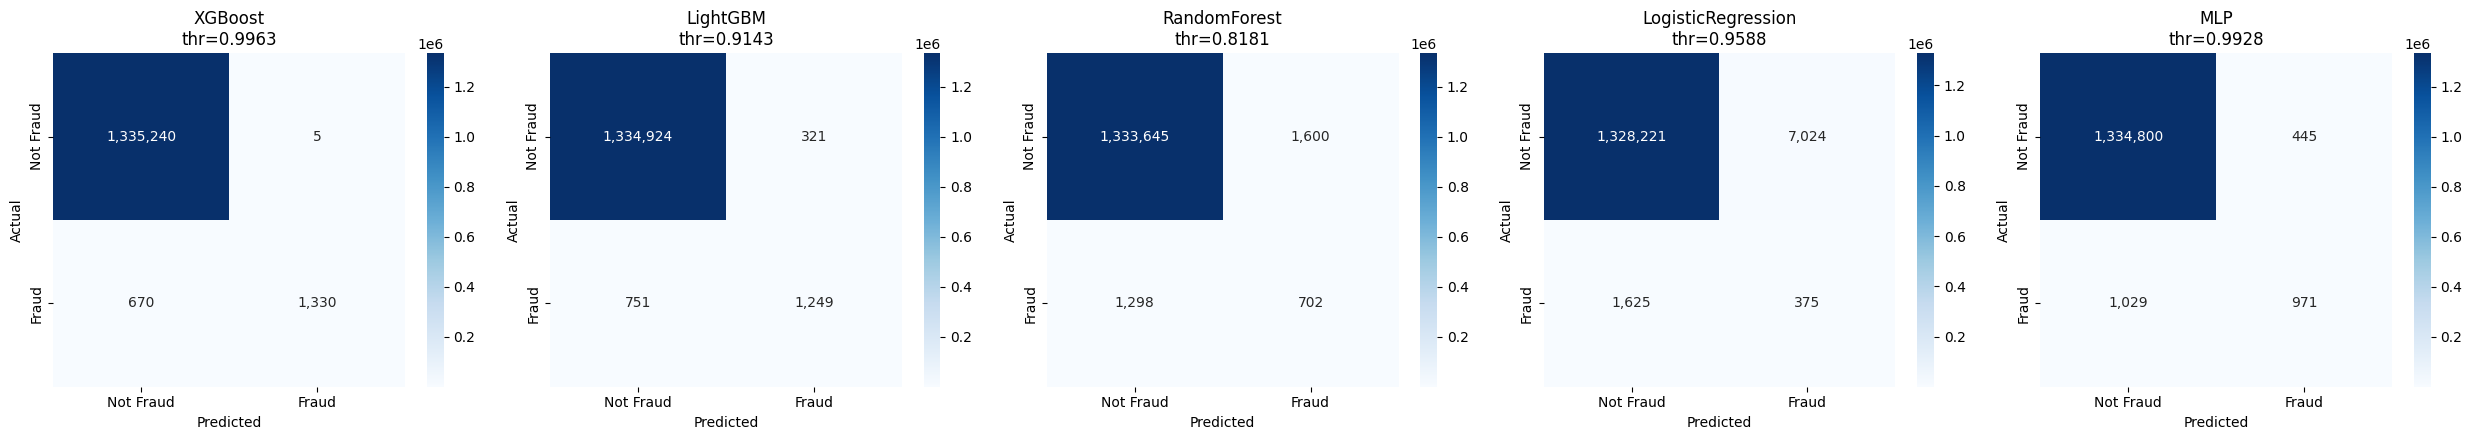

In [29]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    thr  = tuned_thresholds[name]
    pred = (r['test_proba'] >= thr).astype(int)
    cm   = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'])
    ax.set_title(f'{name}\nthr={thr:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
for name, r in results.items():
    thr  = tuned_thresholds[name]
    pred = (r['test_proba'] >= thr).astype(int)
    print(f'\n===== {name}  (threshold = {thr:.4f}) =====')
    print(classification_report(y_test, pred,
          target_names=['Not Fraud', 'Fraud'], digits=4, zero_division=0))


===== XGBoost  (threshold = 0.9963) =====


              precision    recall  f1-score   support

   Not Fraud     0.9995    1.0000    0.9997   1335245
       Fraud     0.9963    0.6650    0.7976      2000

    accuracy                         0.9995   1337245
   macro avg     0.9979    0.8325    0.8987   1337245
weighted avg     0.9995    0.9995    0.9994   1337245


===== LightGBM  (threshold = 0.9143) =====
              precision    recall  f1-score   support

   Not Fraud     0.9994    0.9998    0.9996   1335245
       Fraud     0.7955    0.6245    0.6997      2000

    accuracy                         0.9992   1337245
   macro avg     0.8975    0.8121    0.8497   1337245
weighted avg     0.9991    0.9992    0.9992   1337245


===== RandomForest  (threshold = 0.8181) =====
              precision    recall  f1-score   support

   Not Fraud     0.9990    0.9988    0.9989   1335245
       Fraud     0.3050    0.3510    0.3264      2000

    accuracy                         0.9978   1337245
   macro avg     0.6520    0.6749   

## 7b. Threshold Tuning Plot (best model)

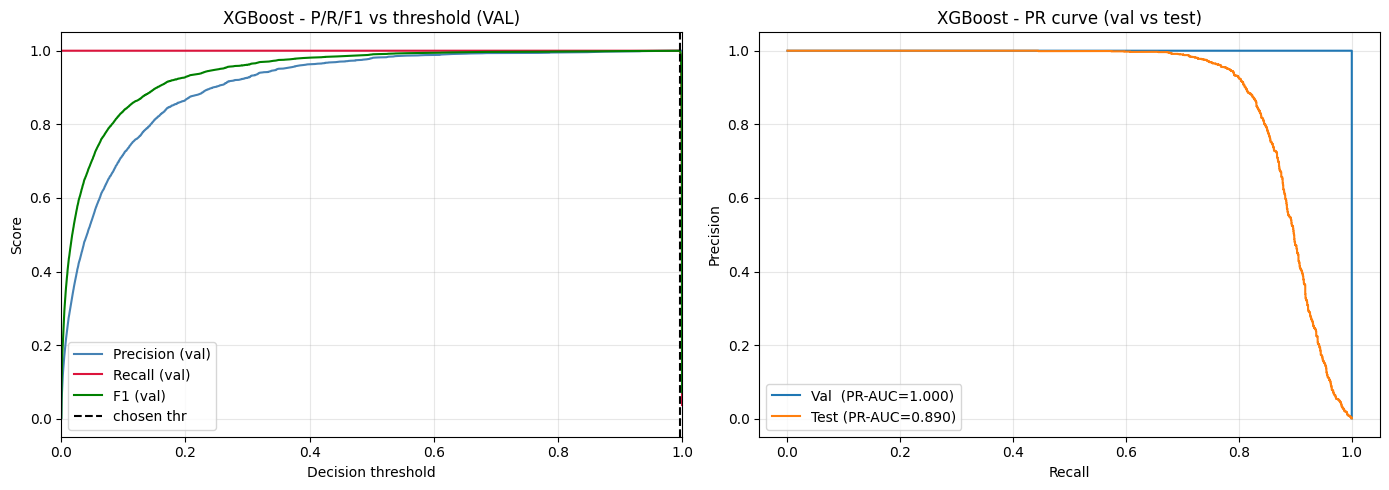

Saved: outputs/threshold_tuning.png


In [31]:
best_name = cmp_default.iloc[0]['Model']
val_p   = results[best_name]['val_proba']
test_p  = results[best_name]['test_proba']

prec_v, rec_v, thr_v = precision_recall_curve(y_val,  val_p)
prec_t, rec_t, _     = precision_recall_curve(y_test, test_p)
prec_va, rec_va, thr_va = prec_v[:-1], rec_v[:-1], thr_v
f1_va = 2 * prec_va * rec_va / (prec_va + rec_va + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(thr_va, prec_va, label='Precision (val)', color='steelblue')
ax.plot(thr_va, rec_va,  label='Recall (val)',    color='crimson')
ax.plot(thr_va, f1_va,   label='F1 (val)',        color='green')
ax.axvline(tuned_thresholds[best_name], color='black', linestyle='--', label='chosen thr')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title(f'{best_name} - P/R/F1 vs threshold (VAL)')
ax.set_xlim(0, 1); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rec_v, prec_v, label=f'Val  (PR-AUC={average_precision_score(y_val,  val_p):.3f})')
ax.plot(rec_t, prec_t, label=f'Test (PR-AUC={average_precision_score(y_test, test_p):.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'{best_name} - PR curve (val vs test)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/threshold_tuning.png')

## 8. Save Best Model
Deploys XGBoost (sklearn pickle - MLP can't be cleanly pickled for FastAPI). Metadata
stores feature order and the val-tuned threshold. FastAPI must use this threshold,
not 0.5.

In [32]:
deploy_name = 'XGBoost' if 'XGBoost' in results else cmp_default.iloc[0]['Model']
best_name   = cmp_default.iloc[0]['Model']
best_model  = results[deploy_name]['model']
print(f'Best model (by test PR-AUC): {best_name}')
print(f'Deploy model                : {deploy_name}')

with open(OUT_DIR / 'model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

metadata = {
    'best_model':       best_name,
    'deploy_model':     deploy_name,
    'feature_order':    list(FEAT_COLS),
    'split': {
        'type':         'stratified_random_70_15_15',
        'random_seed':  RANDOM_SEED,
        'train_rows':   int(len(X_train)),
        'val_rows':     int(len(X_val)),
        'test_rows':    int(len(X_test)),
    },
    'scale_pos_weight': scale_pos_weight,
    'tuned_thresholds': tuned_thresholds,
    'deploy_threshold': tuned_thresholds[deploy_name],
    'metrics_default':  cmp_default.to_dict(orient='records'),
    'metrics_tuned':    cmp_tuned  .to_dict(orient='records'),
}
with open(OUT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: outputs/model.pkl')
print('Saved: outputs/model_metadata.json')
print('Saved: outputs/model_comparison_default.csv')
print('Saved: outputs/model_comparison_tuned.csv')
print(f'\nDeploy threshold: {tuned_thresholds[deploy_name]:.4f}')

Best model (by test PR-AUC): XGBoost
Deploy model                : XGBoost
Saved: outputs/model.pkl
Saved: outputs/model_metadata.json
Saved: outputs/model_comparison_default.csv
Saved: outputs/model_comparison_tuned.csv

Deploy threshold: 0.9963


## Notes
- Honest expectations: XGBoost test PR-AUC ~0.5-0.8 (vs the inflated 0.93 in v1).
  Other models should now also work; order may shuffle.
- FastAPI must use `tuned_thresholds[deploy_name]` from `model_metadata.json`, not 0.5.
- If Optuna runtime is too long, drop to `n_trials=15`.